# Exploratory Data Analysis — Bihar Prohibition (April 2016)

**Author:** [YOUR NAME]
**Treatment:** Bihar Prohibition and Excise Act, 2016 (effective April 5, 2016)
**Treated unit:** Bihar
**Donor pool:** 14 major Indian states
**Study period:** 2010–2022 (annual)
**Primary outcome:** Road accident deaths (MoRTH)
**Secondary outcome:** Own tax revenue — ₹ Crore (RBI Handbook T168)

## Research Question
Did Bihar's April 2016 total prohibition on alcohol cause a reduction in road
accident deaths, relative to the counterfactual trajectory Bihar would have
followed absent the ban?

**Data sources:**
- Road accidents: Ministry of Road Transport & Highways, "Road Accidents in India" (annual PDFs, extracted via camelot)
- Own tax revenue: RBI Handbook of Statistics on Indian States, Table T168
- NSDP per capita: RBI Handbook T19 (FY 2011-12 onwards)
- Urban share / literacy: Census of India 2011 + linear interpolation


In [1]:
%load_ext autoreload
%autoreload 2
import sys, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from src.plotting import (set_publication_style, COLOR_TREATED, COLOR_SYNTHETIC,
                           COLOR_DONORS, COLOR_PLACEBO, treatment_line, save_fig)
set_publication_style()

RESULTS = Path("../results/figures")
RESULTS.mkdir(parents=True, exist_ok=True)


In [2]:
panel = pd.read_csv("../data/processed/bihar_panel.csv", parse_dates=["date"])

TREATED      = "Bihar"
DONORS       = [u for u in panel["unit"].unique() if u != TREATED]
TREATMENT_DATE = "2016-01-01"   # annual data — treat 2016 as treatment year
OUTCOMES     = ["road_accident_deaths", "own_tax_revenue_cr"]
PREDICTORS   = ["nsdp_pc_current_inr", "urban_share_pct", "literacy_rate_pct"]

print(f"Panel shape: {panel.shape}")
print(f"Units ({panel['unit'].nunique()}): {sorted(panel['unit'].unique())}")
print(f"Years: {panel['date'].dt.year.min()} – {panel['date'].dt.year.max()}")
print(f"\nBihar rows:")
print(panel[panel['unit']==TREATED].to_string(index=False))


Panel shape: (195, 8)
Units (15): ['Andhra Pradesh', 'Bihar', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']
Years: 2010 – 2022

Bihar rows:
 unit       date  year  road_accident_deaths  own_tax_revenue_cr  nsdp_pc_current_inr  urban_share_pct  literacy_rate_pct
Bihar 2010-01-01  2010                5137.0              8090.0                  NaN             11.1               63.1
Bihar 2011-01-01  2011                5090.0              9870.0                  NaN             11.3               63.8
Bihar 2012-01-01  2012                5056.0             12612.0              21750.0             11.5               64.5
Bihar 2013-01-01  2013                5061.0             16253.0              24487.0             11.7               65.2
Bihar 2014-01-01  2014                4913.0             19961.0              26948.0             11.9               65.9
Bi

## 1. Descriptive Statistics

In [3]:
# Bihar stats
bihar = panel[panel["unit"] == TREATED].set_index("date")
print("=== Bihar ===")
print(bihar[OUTCOMES + PREDICTORS].describe().round(1))

# Donor pool average
donors = panel[panel["unit"] != TREATED]
donor_avg = donors.groupby("date")[OUTCOMES].mean()
print("\n=== Donor pool mean ===")
print(donor_avg.describe().round(1))


=== Bihar ===
       road_accident_deaths  own_tax_revenue_cr  nsdp_pc_current_inr  \
count                  13.0                13.0                 11.0   
mean                 6024.9             22510.3              34315.4   
std                  1287.4              8746.9               8544.7   
min                  4901.0              8090.0              21750.0   
25%                  5061.0             16253.0              27809.5   
50%                  5421.0             23742.0              34045.0   
75%                  6729.0             30144.0              41421.5   
max                  8898.0             34855.0              47296.0   

       urban_share_pct  literacy_rate_pct  
count             13.0               13.0  
mean              12.3               67.3  
std                0.8                2.7  
min               11.1               63.1  
25%               11.7               65.2  
50%               12.3               67.3  
75%               12.9       

## 2. Outcome Trajectories — Bihar vs Donor Pool Average

  Saved: ../results/figures/eda_bihar_vs_donor_avg.png


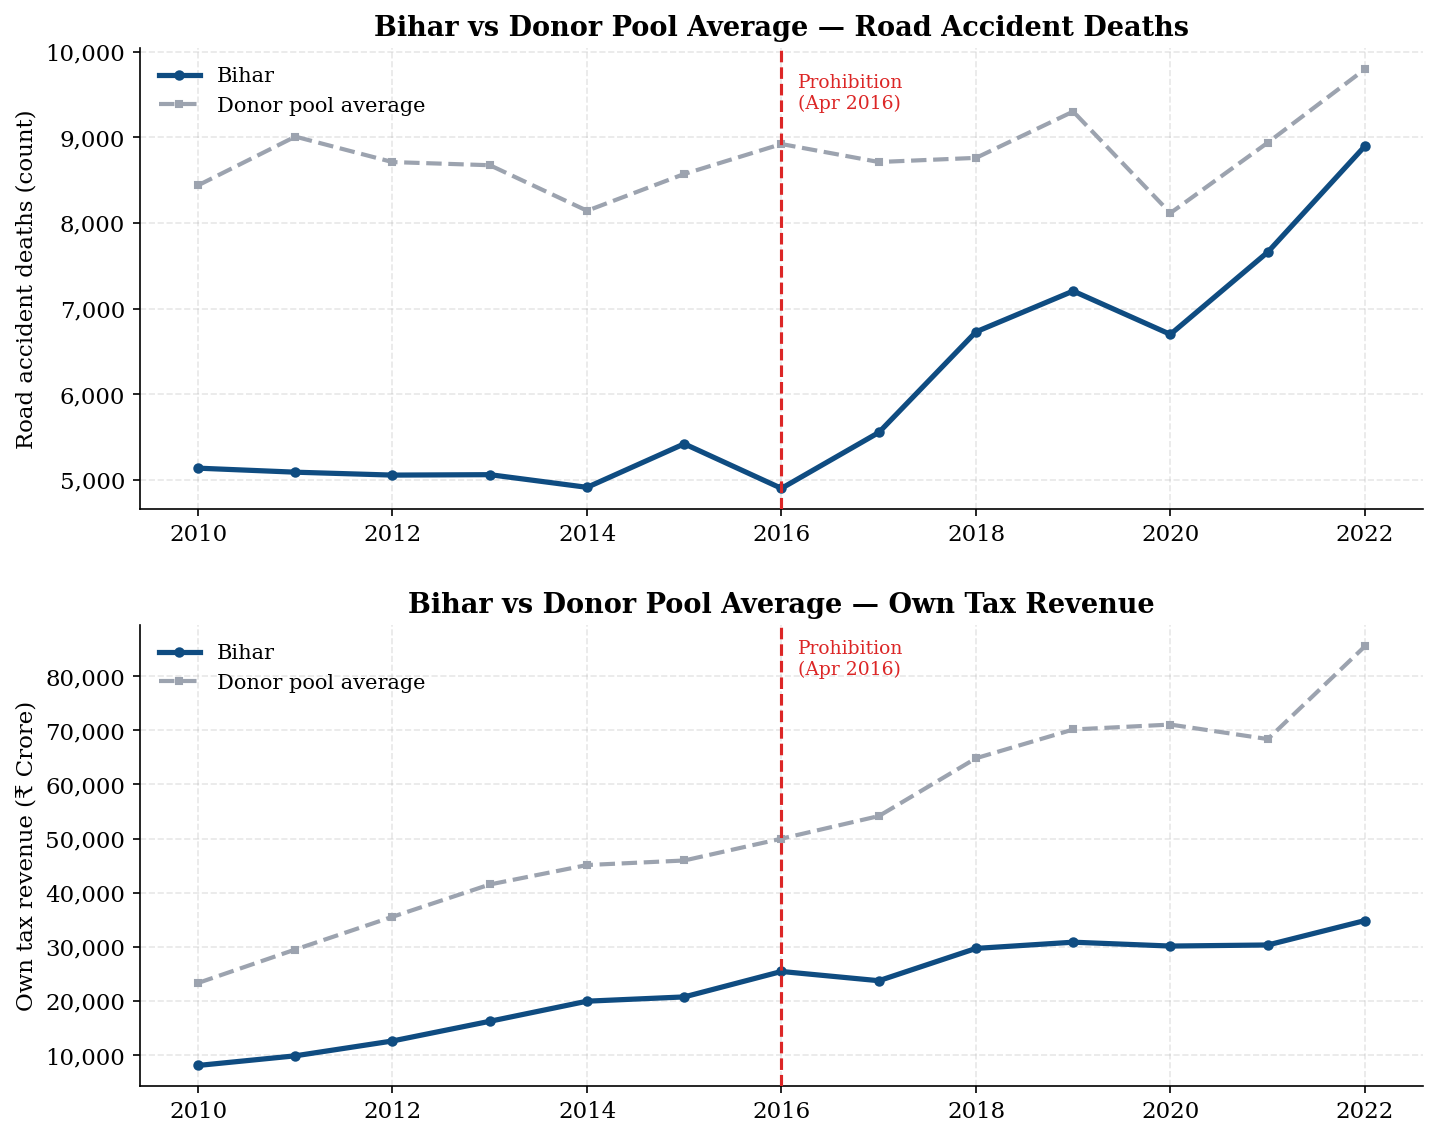

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, outcome, ylabel in zip(axes,
    OUTCOMES,
    ["Road accident deaths (count)", "Own tax revenue (₹ Crore)"]):

    bihar_series = panel[panel["unit"]==TREATED].set_index("date")[outcome]
    donor_mean   = panel[panel["unit"]!=TREATED].groupby("date")[outcome].mean()

    ax.plot(bihar_series.index, bihar_series,
            color=COLOR_TREATED, linewidth=2.5, label="Bihar", marker="o", markersize=4)
    ax.plot(donor_mean.index, donor_mean,
            color=COLOR_DONORS, linewidth=2, linestyle="--",
            label="Donor pool average", marker="s", markersize=3)

    treatment_line(ax, TREATMENT_DATE, label="Prohibition\n(Apr 2016)")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend(loc="upper left")

axes[0].set_title("Bihar vs Donor Pool Average — Road Accident Deaths")
axes[1].set_title("Bihar vs Donor Pool Average — Own Tax Revenue")
fig.tight_layout(pad=2)
save_fig(fig, RESULTS / "eda_bihar_vs_donor_avg.png")
plt.show()


## 3. All Donor Units — Spaghetti Plot

  Saved: ../results/figures/eda_bihar_all_units.png


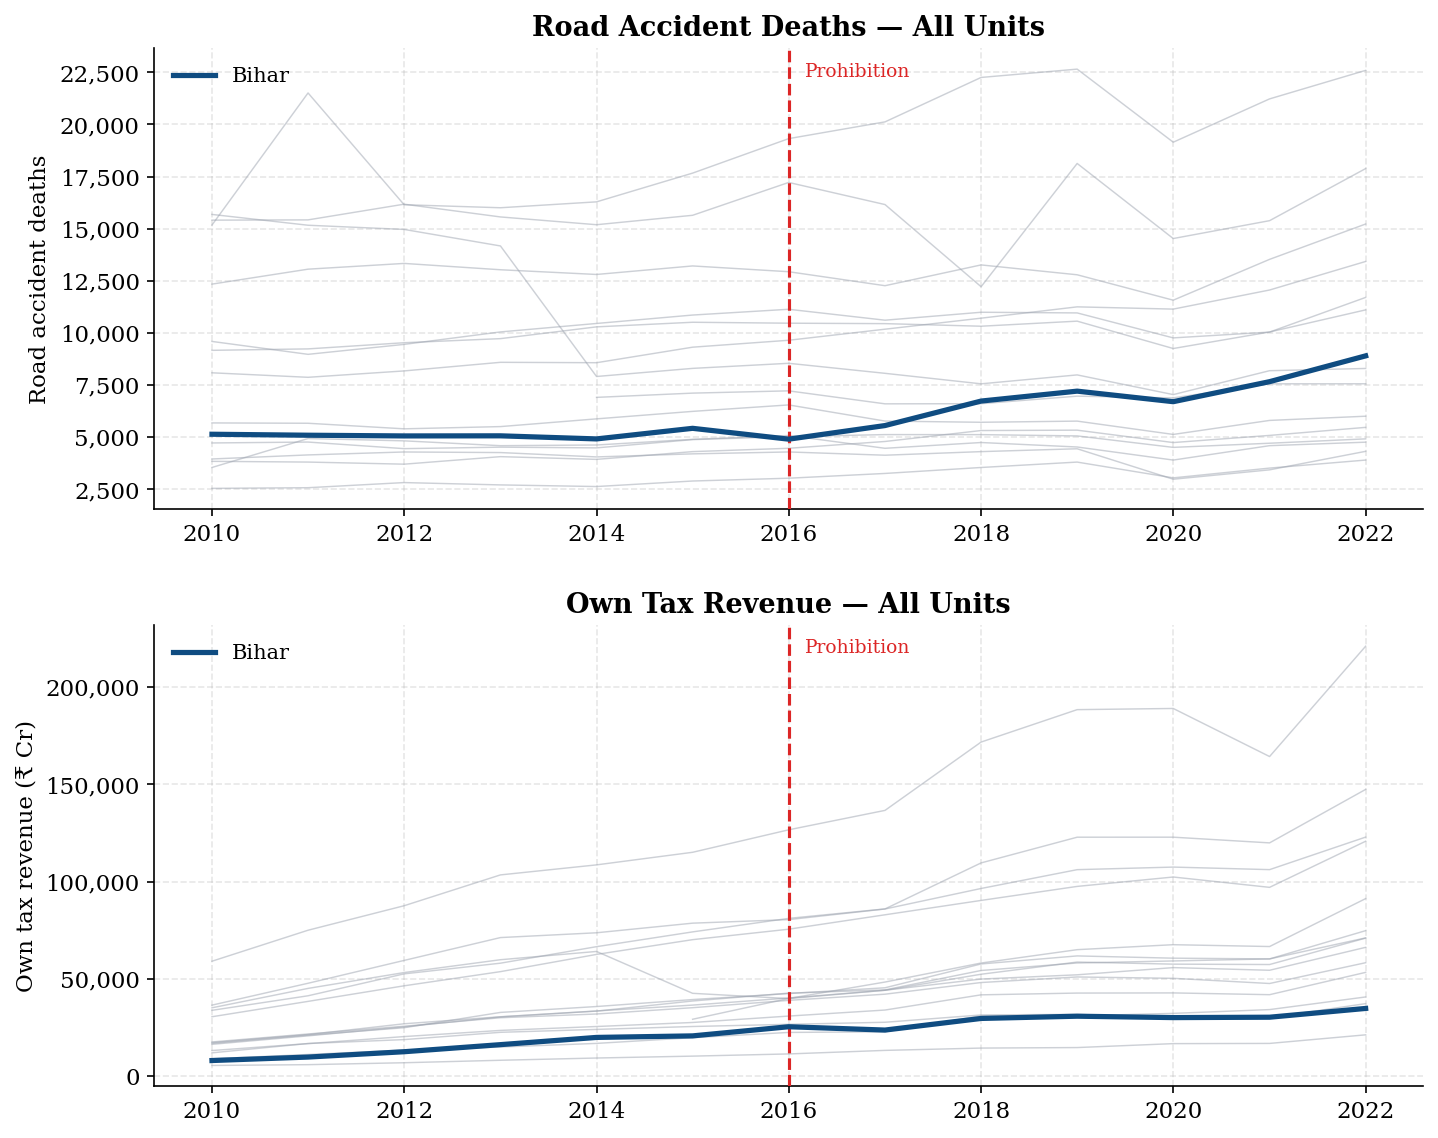

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, outcome, ylabel in zip(axes, OUTCOMES,
    ["Road accident deaths", "Own tax revenue (₹ Cr)"]):

    for unit in DONORS:
        s = panel[panel["unit"]==unit].set_index("date")[outcome]
        ax.plot(s.index, s, color=COLOR_DONORS, linewidth=0.7, alpha=0.5)

    bihar_s = panel[panel["unit"]==TREATED].set_index("date")[outcome]
    ax.plot(bihar_s.index, bihar_s,
            color=COLOR_TREATED, linewidth=2.5, label="Bihar", zorder=10)

    treatment_line(ax, TREATMENT_DATE, label="Prohibition")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.legend()

axes[0].set_title("Road Accident Deaths — All Units")
axes[1].set_title("Own Tax Revenue — All Units")
fig.tight_layout(pad=2)
save_fig(fig, RESULTS / "eda_bihar_all_units.png")
plt.show()


## 4. Pre-Treatment Parallel Trends Check

The key SCM assumption is that the synthetic control can track Bihar's
pre-treatment trajectory. Here we check visually and via correlation.

In [6]:
# Pre-treatment only
pre = panel[panel["date"] < TREATMENT_DATE]
pivot = pre.pivot(index="date", columns="unit", values="road_accident_deaths")

# Correlation of each donor with Bihar in pre-period
corr = pivot.corr()[TREATED].drop(TREATED).sort_values(ascending=False)
print("Pre-treatment correlation with Bihar — Road Accident Deaths:")
print(corr.round(3).to_string())


Pre-treatment correlation with Bihar — Road Accident Deaths:
unit
Telangana         1.000
Haryana           0.818
Odisha            0.668
West Bengal       0.627
Madhya Pradesh    0.589
Jharkhand         0.559
Karnataka         0.370
Rajasthan         0.296
Maharashtra       0.225
Tamil Nadu        0.225
Uttar Pradesh     0.156
Kerala            0.151
Punjab            0.094
Andhra Pradesh   -0.194


  Saved: ../results/figures/eda_bihar_pretrend_top5.png


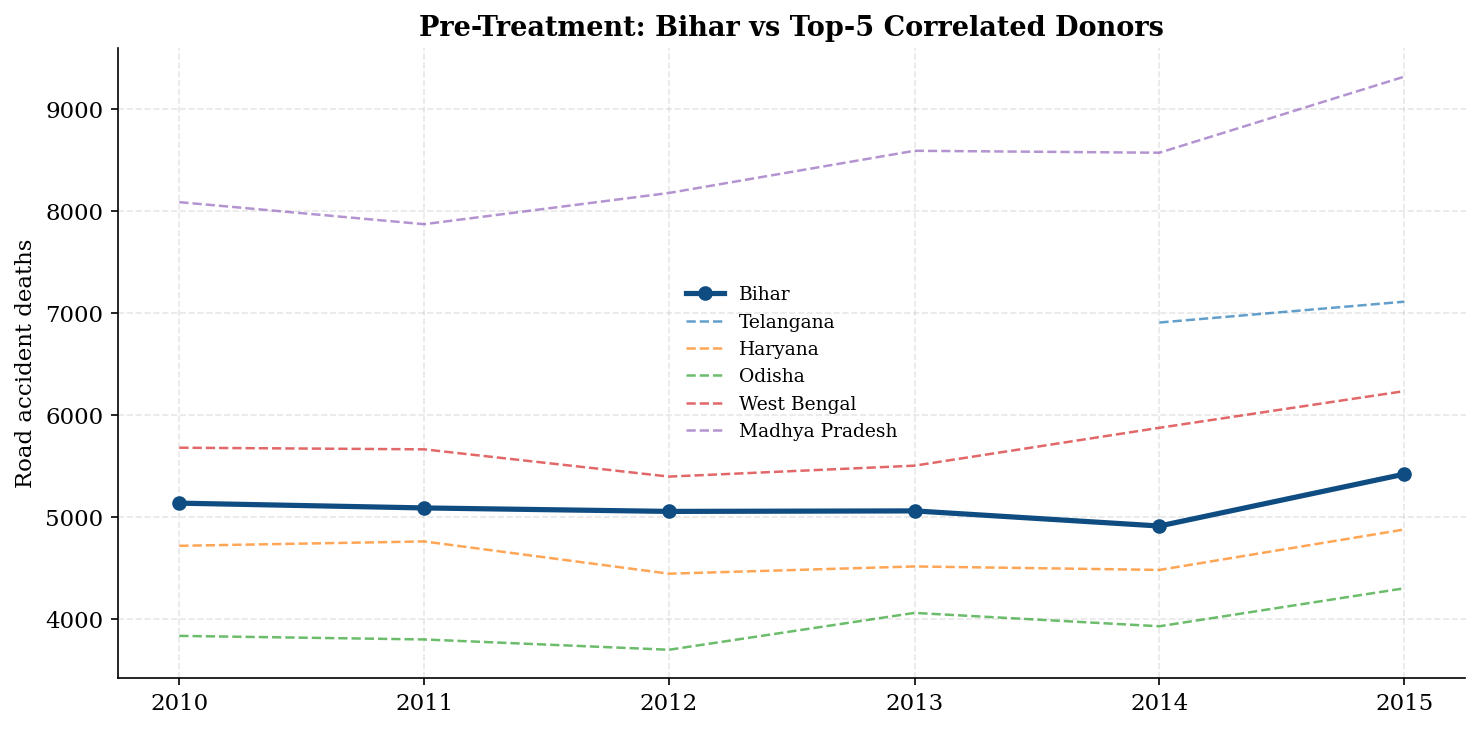

In [7]:
# Visualise pre-treatment fit quality
fig, ax = plt.subplots(figsize=(10, 5))
bihar_pre = pre[pre["unit"]==TREATED].set_index("date")["road_accident_deaths"]
ax.plot(bihar_pre.index, bihar_pre,
        color=COLOR_TREATED, linewidth=2.5, label="Bihar", marker="o")

# Top 5 correlated donors
top5 = corr.head(5).index.tolist()
for unit in top5:
    s = pre[pre["unit"]==unit].set_index("date")["road_accident_deaths"]
    ax.plot(s.index, s, linewidth=1.2, linestyle="--", alpha=0.7, label=unit)

ax.set_title("Pre-Treatment: Bihar vs Top-5 Correlated Donors")
ax.set_ylabel("Road accident deaths")
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, RESULTS / "eda_bihar_pretrend_top5.png")
plt.show()


## 5. Predictor Balance Table
How different is Bihar from the donor pool on matching predictors?

In [8]:
# Use 2012-2015 window (NSDP available from 2012)
match_window = panel[
    (panel["date"] >= "2012-01-01") & (panel["date"] < TREATMENT_DATE)
]

bihar_pred = match_window[match_window["unit"]==TREATED][PREDICTORS].mean()
donor_pred = match_window[match_window["unit"]!=TREATED][PREDICTORS].mean()

balance = pd.DataFrame({
    "Bihar (pre-mean)": bihar_pred,
    "Donor avg (pre-mean)": donor_pred,
    "Ratio": (bihar_pred / donor_pred).round(2),
})
print("=== Predictor Balance: Bihar vs Donor Pool Average ===")
print(balance.round(1).to_string())


=== Predictor Balance: Bihar vs Donor Pool Average ===
                     Bihar (pre-mean)  Donor avg (pre-mean)  Ratio
nsdp_pc_current_inr           25464.0               84934.9    0.3
urban_share_pct                  11.8                  34.5    0.3
literacy_rate_pct                65.6                  75.2    0.9


## 6. Data Quality Audit

In [9]:
print("Missing values by column:")
print(panel.isna().sum())
print("\nMissing by unit (total NaNs):")
print(panel.groupby("unit").apply(lambda d: d.isna().sum().sum()).sort_values(ascending=False).head(10))
print("\nNotes:")
print("- Telangana 2010-2013: state did not exist (bifurcated from Andhra Pradesh June 2014)")
print("- nsdp_pc_current_inr 2010-2011: RBI Handbook T19 series starts FY 2011-12")
print("- own_tax_revenue 2010-2014 Telangana: RBI did not publish separately pre-bifurcation")


Missing values by column:
unit                     0
date                     0
year                     0
road_accident_deaths     4
own_tax_revenue_cr       5
nsdp_pc_current_inr     30
urban_share_pct          0
literacy_rate_pct        0
dtype: int64

Missing by unit (total NaNs):
unit
Telangana         11
Bihar              2
Andhra Pradesh     2
Jharkhand          2
Karnataka          2
Kerala             2
Haryana            2
Madhya Pradesh     2
Maharashtra        2
Punjab             2
dtype: int64

Notes:
- Telangana 2010-2013: state did not exist (bifurcated from Andhra Pradesh June 2014)
- nsdp_pc_current_inr 2010-2011: RBI Handbook T19 series starts FY 2011-12
- own_tax_revenue 2010-2014 Telangana: RBI did not publish separately pre-bifurcation


## 7. Implications for SCM Design

**Donor pool:** 14 states. Telangana excluded from pre-2014 matching (state did not exist).
Recommend dropping Telangana from the donor pool entirely OR setting matching
window to 2014-2015 only — though that leaves only 2 pre-treatment periods.
**Decision: exclude Telangana from donor pool in SCM.**

**Predictor matching window:** 2012–2015 (4 years; limited by NSDP data availability).
Document explicitly in the SCM notebook.

**Pre-trend quality:** [Fill in after running Cell 11 — which donors correlate
highest with Bihar? Does anyone track Bihar closely pre-2016?]

**Primary outcome:** road_accident_deaths
The +44% post-treatment increase in raw Bihar deaths must be compared against
the counterfactual Bihar (the synthetic control). National vehicle growth affects
all states; the SCM gap isolates the prohibition-specific component.

**Secondary outcome:** own_tax_revenue_cr
Treatment effect will be attenuated because non-excise tax growth offsets excise
collapse in this composite. Interpret with caution.

**Caveats:**
1. Annual data gives only 6 pre-treatment points (2010-2015); 4 with NSDP (2012-2015)
2. Telangana bifurcation 2014 creates a structural break in AP+Telangana combined series
3. 2020-2021 COVID shock affects both treated and donors — keep in post-period but note
4. Census predictor interpolation introduces smoothness that real data would not have
